In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
img_path = "../data/raw/Training/glioma/Tr-gl_10.jpg" # change image

img = cv2.imread(img_path)
img = cv2.resize(img, (224,224))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [3]:
_, mask = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

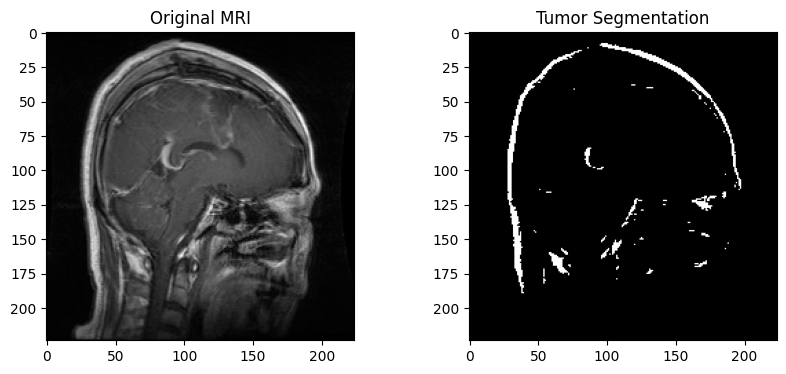

In [5]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original MRI")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Tumor Segmentation")

plt.show()

In [6]:
# Remove noise
kernel = np.ones((3,3), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# Dilate to highlight tumor region
mask = cv2.dilate(mask, kernel, iterations=1)

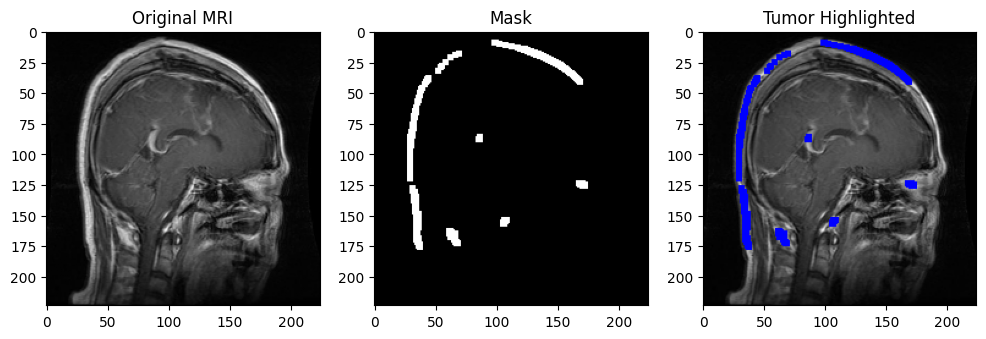

In [7]:
# Overlay mask on original image
overlay = img.copy()
overlay[mask == 255] = [0, 0, 255]  # Red tumor

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original MRI")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Tumor Highlighted")

plt.show()

In [8]:
h, w = gray.shape
mask_center = np.zeros_like(mask)

mask_center[h//4:3*h//4, w//4:3*w//4] = mask[h//4:3*h//4, w//4:3*w//4]

In [9]:
# Remove small objects
kernel = np.ones((5,5), np.uint8)
mask_clean = cv2.morphologyEx(mask_center, cv2.MORPH_OPEN, kernel)

In [10]:
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

mask_final = np.zeros_like(mask_clean)

if contours:
    c = max(contours, key=cv2.contourArea)
    cv2.drawContours(mask_final, [c], -1, 255, -1)

In [11]:
overlay = img.copy()
overlay[mask_final == 255] = [0, 0, 255]

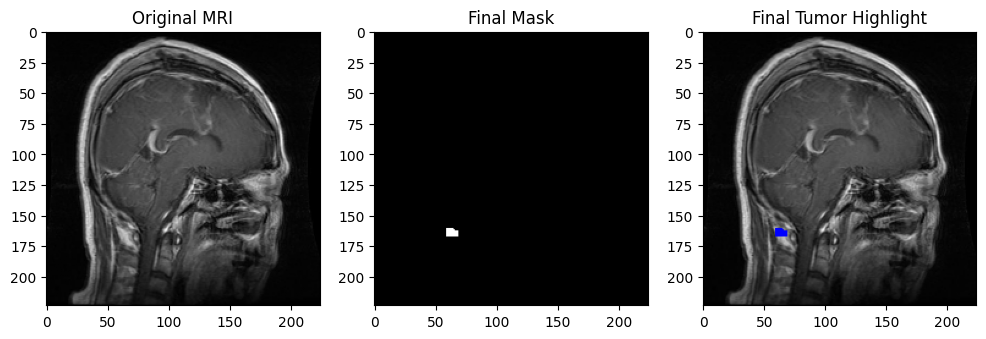

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original MRI")

plt.subplot(1,3,2)
plt.imshow(mask_final, cmap='gray')
plt.title("Final Mask")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Final Tumor Highlight")

plt.show()